<a href="https://colab.research.google.com/github/delishashibu28-bot/heart-disease-prediction-data/blob/main/patients_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# With HadHeartAttack as the prediction variable, the task would involve using other features in the dataset to predict whether a patient has experienced a heart attack. This could be approached as a binary classification problem, where the model learns patterns from the other variables to predict the likelihood of HadHeartAttack (0 for no, 1 for yes).


Heart disease is one of the leading causes of mortality worldwide, with heart attacks being a primary manifestation. Early detection and intervention can significantly reduce the risk and improve patient outcomes. In this project, we aim to develop a predictive model that leverages patient demographic, health, and lifestyle information to determine the likelihood of a heart attack occurrence. By analyzing this data, healthcare providers may gain insights into high-risk patients, enabling proactive measures and better allocation of medical resources.

The objective is to predict whether a patient has had a heart attack (binary outcome: HadHeartAttack) based on a range of features, including medical history, lifestyle habits, and demographic details. This model could serve as an assistive tool in clinical decision-making and help in implementing preventive healthcare strategies.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/Patients Data ( Used for Heart Disease Prediction ) (2).csv')
df.head()

,PatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,Fair,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,Never used e-cigarettes in my entire life,1,"White only, Non-Hispanic",0,0,0,1,"No, did not receive any tetanus shot in the pa...",0,1
1,2,Alabama,Female,Very good,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received Tdap",0,0
2,3,Alabama,Male,Excellent,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",1,0,0,0,"Yes, received tetanus shot but not sure what type",0,0
3,4,Alabama,Male,Very good,Age 70 to 74,1.78,95.250000,30.129999,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received tetanus shot but not sure what type",0,0
4,5,Alabama,Female,Good,Age 50 to 54,1.68,78.019997,27.760000,0,0,...,Never used e-cigarettes in my entire life,1,"Black only, Non-Hispanic",0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0


In [ ]:
df.tail()

,PatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
237625,237626,Puerto Rico,Female,Good,Age 60 to 64,1.57,90.720001,36.580002,0,0,...,Not at all (right now),0,Hispanic,0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
237626,237627,Puerto Rico,Female,Good,Age 55 to 59,1.70,72.570000,25.059999,0,1,...,Not at all (right now),0,Hispanic,0,1,0,0,"Yes, received Tdap",0,0
237627,237628,Puerto Rico,Male,Fair,Age 45 to 49,1.75,70.309998,22.889999,1,1,...,Not at all (right now),1,Hispanic,0,1,1,1,"Yes, received Tdap",1,0
237628,237629,Puerto Rico,Female,Very good,Age 25 to 29,1.57,46.720001,18.840000,0,0,...,Never used e-cigarettes in my entire life,0,Hispanic,0,1,0,0,"No, did not receive any tetanus shot in the pa...",0,1
237629,237630,Puerto Rico,Female,Good,Age 30 to 34,1.60,83.010002,32.419998,0,0,...,Never used e-cigarettes in my entire life,1,Hispanic,0,1,0,0,"No, did not receive any tetanus shot in the pa...",0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   PatientID                  237630 non-null  int64  
 1   State                      237630 non-null  object 
 2   Sex                        237630 non-null  object 
 3   GeneralHealth              237630 non-null  object 
 4   AgeCategory                237630 non-null  object 
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

In [ ]:
df.isnull().sum()

,0
PatientID,0
State,0
Sex,0
GeneralHealth,0
AgeCategory,0
HeightInMeters,0
WeightInKilograms,0
BMI,0
HadHeartAttack,0
HadAngina,0


In [ ]:
print(df['ECigaretteUsage'].unique())

['Never used e-cigarettes in my entire life' 'Not at all (right now)'
 'Use them some days' 'Use them every day']


In [ ]:
print(df['GeneralHealth'].unique())

['Fair' 'Very good' 'Excellent' 'Good' 'Poor']


In [ ]:
df['ECigaretteUsage'].replace(['Never used e-cigarettes in my entire life','Not at all (right now)','Use them some days','Use them every day'],[1,2,3,4],inplace=True)

/tmp/ipykernel_12957/3971037403.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ECigaretteUsage'].replace(['Never used e-cigarettes in my entire life','Not at all (right now)','Use them some days','Use them every day'],[1,2,3,4],inplace=True)
/tmp/ipykernel_12957/3971037403.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('futur

In [ ]:
df['GeneralHealth'].replace(['Poor', 'Fair', 'Good', 'Very good', 'Excellent'],[1,2,3,4,5],inplace=True)

/tmp/ipykernel_12957/2441845280.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['GeneralHealth'].replace(['Poor', 'Fair', 'Good', 'Very good', 'Excellent'],[1,2,3,4,5],inplace=True)
/tmp/ipykernel_12957/2441845280.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['GeneralHealth'].replace

In [ ]:
df

,PatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,2,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,1,1,"White only, Non-Hispanic",0,0,0,1,"No, did not receive any tetanus shot in the pa...",0,1
1,2,Alabama,Female,4,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,1,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received Tdap",0,0
2,3,Alabama,Male,5,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,1,0,"White only, Non-Hispanic",1,0,0,0,"Yes, received tetanus shot but not sure what type",0,0
3,4,Alabama,Male,4,Age 70 to 74,1.78,95.250000,30.129999,0,0,...,1,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received tetanus shot but not sure what type",0,0
4,5,Alabama,Female,3,Age 50 to 54,1.68,78.019997,27.760000,0,0,...,1,1,"Black only, Non-Hispanic",0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237625,237626,Puerto Rico,Female,3,Age 60 to 64,1.57,90.720001,36.580002,0,0,...,2,0,Hispanic,0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
237626,237627,Puerto Rico,Female,3,Age 55 to 59,1.70,72.570000,25.059999,0,1,...,2,0,Hispanic,0,1,0,0,"Yes, received Tdap",0,0
237627,237628,Puerto Rico,Male,2,Age 45 to 49,1.75,70.309998,22.889999,1,1,...,2,1,Hispanic,0,1,1,1,"Yes, received Tdap",1,0
237628,237629,Puerto Rico,Female,4,Age 25 to 29,1.57,46.720001,18.840000,0,0,...,1,0,Hispanic,0,1,0,0,"No, did not receive any tetanus shot in the pa...",0,1


In [ ]:
print(df['AgeCategory'].unique())

['Age 75 to 79' 'Age 65 to 69' 'Age 60 to 64' 'Age 70 to 74'
 'Age 50 to 54' 'Age 80 or older' 'Age 55 to 59' 'Age 25 to 29'
 'Age 40 to 44' 'Age 30 to 34' 'Age 35 to 39' 'Age 18 to 24'
 'Age 45 to 49']


In [ ]:
df['AgeCategory'].replace(['Age 18 to 24', 'Age 25 to 29', 'Age 30 to 34', 'Age 35 to 39', 'Age 40 to 44', 'Age 45 to 49', 'Age 50 to 54', 'Age 55 to 59', 'Age 60 to 64', 'Age 65 to 69', 'Age 70 to 74', 'Age 75 to 79', 'Age 80 or older'],[21,27,32,37,42,47,52,57,62,67,72,77,85],inplace=True)

/tmp/ipykernel_12957/3214422434.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['AgeCategory'].replace(['Age 18 to 24', 'Age 25 to 29', 'Age 30 to 34', 'Age 35 to 39', 'Age 40 to 44', 'Age 45 to 49', 'Age 50 to 54', 'Age 55 to 59', 'Age 60 to 64', 'Age 65 to 69', 'Age 70 to 74', 'Age 75 to 79', 'Age 80 or older'],[21,27,32,37,42,47,52,57,62,67,72,77,85],inplace=True)
/tmp/ipykernel_12957/3214422434.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the

In [ ]:
df['AgeCategory'].unique()

array([77, 67, 62, 72, 52, 85, 57, 27, 42, 32, 37, 21, 47])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   PatientID                  237630 non-null  int64  
 1   State                      237630 non-null  object 
 2   Sex                        237630 non-null  object 
 3   GeneralHealth              237630 non-null  int64  
 4   AgeCategory                237630 non-null  int64  
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

In [ ]:
df

,PatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,2,77,1.63,84.820000,32.099998,0,1,...,1,1,"White only, Non-Hispanic",0,0,0,1,"No, did not receive any tetanus shot in the pa...",0,1
1,2,Alabama,Female,4,67,1.60,71.669998,27.990000,0,0,...,1,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received Tdap",0,0
2,3,Alabama,Male,5,62,1.78,71.209999,22.530001,0,0,...,1,0,"White only, Non-Hispanic",1,0,0,0,"Yes, received tetanus shot but not sure what type",0,0
3,4,Alabama,Male,4,72,1.78,95.250000,30.129999,0,0,...,1,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received tetanus shot but not sure what type",0,0
4,5,Alabama,Female,3,52,1.68,78.019997,27.760000,0,0,...,1,1,"Black only, Non-Hispanic",0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237625,237626,Puerto Rico,Female,3,62,1.57,90.720001,36.580002,0,0,...,2,0,Hispanic,0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
237626,237627,Puerto Rico,Female,3,57,1.70,72.570000,25.059999,0,1,...,2,0,Hispanic,0,1,0,0,"Yes, received Tdap",0,0
237627,237628,Puerto Rico,Male,2,47,1.75,70.309998,22.889999,1,1,...,2,1,Hispanic,0,1,1,1,"Yes, received Tdap",1,0
237628,237629,Puerto Rico,Female,4,27,1.57,46.720001,18.840000,0,0,...,1,0,Hispanic,0,1,0,0,"No, did not receive any tetanus shot in the pa...",0,1


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(237630, 35)

In [ ]:
df

,PatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,2,77,1.63,84.820000,32.099998,0,1,...,1,1,"White only, Non-Hispanic",0,0,0,1,"No, did not receive any tetanus shot in the pa...",0,1
1,2,Alabama,Female,4,67,1.60,71.669998,27.990000,0,0,...,1,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received Tdap",0,0
2,3,Alabama,Male,5,62,1.78,71.209999,22.530001,0,0,...,1,0,"White only, Non-Hispanic",1,0,0,0,"Yes, received tetanus shot but not sure what type",0,0
3,4,Alabama,Male,4,72,1.78,95.250000,30.129999,0,0,...,1,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received tetanus shot but not sure what type",0,0
4,5,Alabama,Female,3,52,1.68,78.019997,27.760000,0,0,...,1,1,"Black only, Non-Hispanic",0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237625,237626,Puerto Rico,Female,3,62,1.57,90.720001,36.580002,0,0,...,2,0,Hispanic,0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
237626,237627,Puerto Rico,Female,3,57,1.70,72.570000,25.059999,0,1,...,2,0,Hispanic,0,1,0,0,"Yes, received Tdap",0,0
237627,237628,Puerto Rico,Male,2,47,1.75,70.309998,22.889999,1,1,...,2,1,Hispanic,0,1,1,1,"Yes, received Tdap",1,0
237628,237629,Puerto Rico,Female,4,27,1.57,46.720001,18.840000,0,0,...,1,0,Hispanic,0,1,0,0,"No, did not receive any tetanus shot in the pa...",0,1


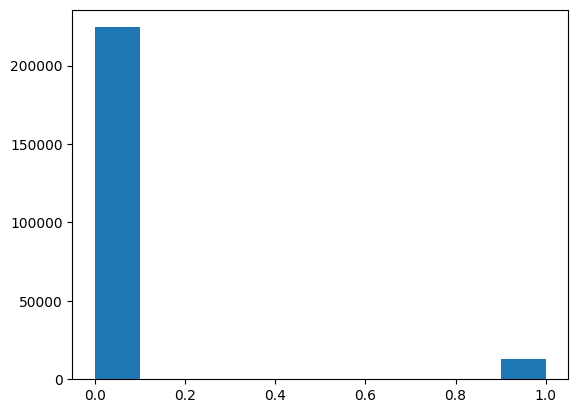

In [ ]:
plt.hist(df["HadHeartAttack"])
plt.show()

In [ ]:
df

,PatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,2,77,1.63,84.820000,32.099998,0,1,...,1,1,"White only, Non-Hispanic",0,0,0,1,"No, did not receive any tetanus shot in the pa...",0,1
1,2,Alabama,Female,4,67,1.60,71.669998,27.990000,0,0,...,1,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received Tdap",0,0
2,3,Alabama,Male,5,62,1.78,71.209999,22.530001,0,0,...,1,0,"White only, Non-Hispanic",1,0,0,0,"Yes, received tetanus shot but not sure what type",0,0
3,4,Alabama,Male,4,72,1.78,95.250000,30.129999,0,0,...,1,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received tetanus shot but not sure what type",0,0
4,5,Alabama,Female,3,52,1.68,78.019997,27.760000,0,0,...,1,1,"Black only, Non-Hispanic",0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237625,237626,Puerto Rico,Female,3,62,1.57,90.720001,36.580002,0,0,...,2,0,Hispanic,0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
237626,237627,Puerto Rico,Female,3,57,1.70,72.570000,25.059999,0,1,...,2,0,Hispanic,0,1,0,0,"Yes, received Tdap",0,0
237627,237628,Puerto Rico,Male,2,47,1.75,70.309998,22.889999,1,1,...,2,1,Hispanic,0,1,1,1,"Yes, received Tdap",1,0
237628,237629,Puerto Rico,Female,4,27,1.57,46.720001,18.840000,0,0,...,1,0,Hispanic,0,1,0,0,"No, did not receive any tetanus shot in the pa...",0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   PatientID                  237630 non-null  int64  
 1   State                      237630 non-null  object 
 2   Sex                        237630 non-null  object 
 3   GeneralHealth              237630 non-null  int64  
 4   AgeCategory                237630 non-null  int64  
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['State']=le.fit_transform(df['State'])
df['Sex']=le.fit_transform(df['Sex'])
df['Sex']=le.fit_transform(df['Sex'])
df['HadDiabetes']=le.fit_transform(df['HadDiabetes'])
df['SmokerStatus']=le.fit_transform(df['SmokerStatus'])
df['RaceEthnicityCategory']=le.fit_transform(df['RaceEthnicityCategory'])
df['TetanusLast10Tdap']=le.fit_transform(df['TetanusLast10Tdap'])

In [ ]:
dummies=pd.get_dummies(df["Sex"]).astype(int)
dummies

,0,1
0,1,0
1,1,0
2,0,1
3,0,1
4,1,0
...,...,...
237625,1,0
237626,1,0
237627,0,1
237628,1,0


In [ ]:
df.drop(["State","PatientID","HeightInMeters","WeightInKilograms","FluVaxLast12","PneumoVaxEver","HIVTesting","ChestScan","CovidPos","HighRiskLastYear","ECigaretteUsage","TetanusLast10Tdap"],axis=1,inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 23 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Sex                        237630 non-null  int64  
 1   GeneralHealth              237630 non-null  int64  
 2   AgeCategory                237630 non-null  int64  
 3   BMI                        237630 non-null  float64
 4   HadHeartAttack             237630 non-null  int64  
 5   HadAngina                  237630 non-null  int64  
 6   HadStroke                  237630 non-null  int64  
 7   HadAsthma                  237630 non-null  int64  
 8   HadSkinCancer              237630 non-null  int64  
 9   HadCOPD                    237630 non-null  int64  
 10  HadDepressiveDisorder      237630 non-null  int64  
 11  HadKidneyDisease           237630 non-null  int64  
 12  HadArthritis               237630 non-null  int64  
 13  HadDiabetes                23

In [ ]:
df.isnull().sum()

,0
Sex,0
GeneralHealth,0
AgeCategory,0
BMI,0
HadHeartAttack,0
HadAngina,0
HadStroke,0
HadAsthma,0
HadSkinCancer,0
HadCOPD,0


In [ ]:
df

,Sex,GeneralHealth,AgeCategory,BMI,HadHeartAttack,HadAngina,HadStroke,HadAsthma,HadSkinCancer,HadCOPD,...,HadDiabetes,DeafOrHardOfHearing,BlindOrVisionDifficulty,DifficultyConcentrating,DifficultyWalking,DifficultyDressingBathing,DifficultyErrands,SmokerStatus,RaceEthnicityCategory,AlcoholDrinkers
0,0,2,77,32.099998,0,1,0,1,1,0,...,2,0,0,0,1,0,0,2,4,0
1,0,4,67,27.990000,0,0,0,0,0,0,...,0,0,0,0,0,0,0,2,4,0
2,1,5,62,22.530001,0,0,0,0,0,0,...,0,0,0,0,0,0,0,3,4,1
3,1,4,72,30.129999,0,0,0,0,0,0,...,2,0,0,0,0,0,0,2,4,0
4,0,3,52,27.760000,0,0,0,0,0,0,...,0,0,0,0,0,0,0,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237625,0,3,62,36.580002,0,0,0,0,0,0,...,2,0,1,0,0,0,0,3,1,0
237626,0,3,57,25.059999,0,1,0,0,0,0,...,0,0,0,0,0,0,0,2,1,0
237627,1,2,47,22.889999,1,1,0,0,0,0,...,0,0,0,1,1,1,0,0,1,0
237628,0,4,27,18.840000,0,0,0,0,0,0,...,0,0,0,0,0,0,0,3,1,0


In [ ]:
df.isnull().sum()

,0
Sex,0
GeneralHealth,0
AgeCategory,0
BMI,0
HadHeartAttack,0
HadAngina,0
HadStroke,0
HadAsthma,0
HadSkinCancer,0
HadCOPD,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 23 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Sex                        237630 non-null  int64  
 1   GeneralHealth              237630 non-null  int64  
 2   AgeCategory                237630 non-null  int64  
 3   BMI                        237630 non-null  float64
 4   HadHeartAttack             237630 non-null  int64  
 5   HadAngina                  237630 non-null  int64  
 6   HadStroke                  237630 non-null  int64  
 7   HadAsthma                  237630 non-null  int64  
 8   HadSkinCancer              237630 non-null  int64  
 9   HadCOPD                    237630 non-null  int64  
 10  HadDepressiveDisorder      237630 non-null  int64  
 11  HadKidneyDisease           237630 non-null  int64  
 12  HadArthritis               237630 non-null  int64  
 13  HadDiabetes                23

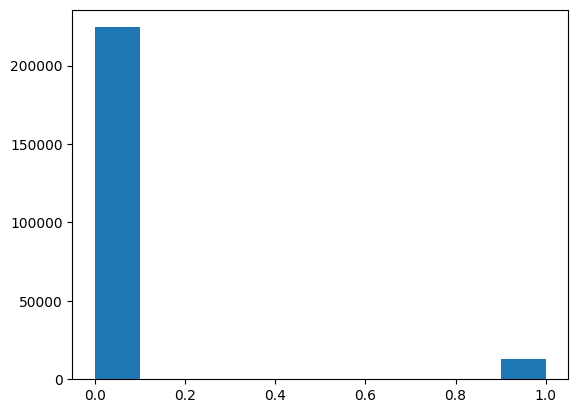

In [ ]:
plt.hist(df["HadHeartAttack"])
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 23 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Sex                        237630 non-null  int64  
 1   GeneralHealth              237630 non-null  int64  
 2   AgeCategory                237630 non-null  int64  
 3   BMI                        237630 non-null  float64
 4   HadHeartAttack             237630 non-null  int64  
 5   HadAngina                  237630 non-null  int64  
 6   HadStroke                  237630 non-null  int64  
 7   HadAsthma                  237630 non-null  int64  
 8   HadSkinCancer              237630 non-null  int64  
 9   HadCOPD                    237630 non-null  int64  
 10  HadDepressiveDisorder      237630 non-null  int64  
 11  HadKidneyDisease           237630 non-null  int64  
 12  HadArthritis               237630 non-null  int64  
 13  HadDiabetes                23

In [ ]:
df.isnull().sum()

,0
Sex,0
GeneralHealth,0
AgeCategory,0
BMI,0
HadHeartAttack,0
HadAngina,0
HadStroke,0
HadAsthma,0
HadSkinCancer,0
HadCOPD,0


In [ ]:
from imblearn.over_sampling import SMOTE
x= df.drop("HadHeartAttack",axis=1)
y = df['HadHeartAttack']
smote= SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(x,y)



In [ ]:
df_resampled = pd.concat([X_resampled, y_resampled], axis=1)


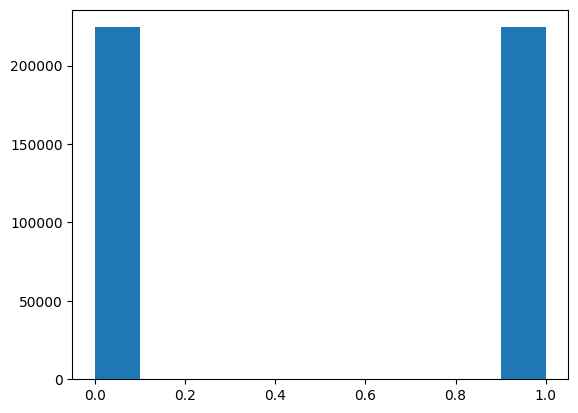

In [ ]:
plt.hist(df_resampled["HadHeartAttack"])
plt.show()

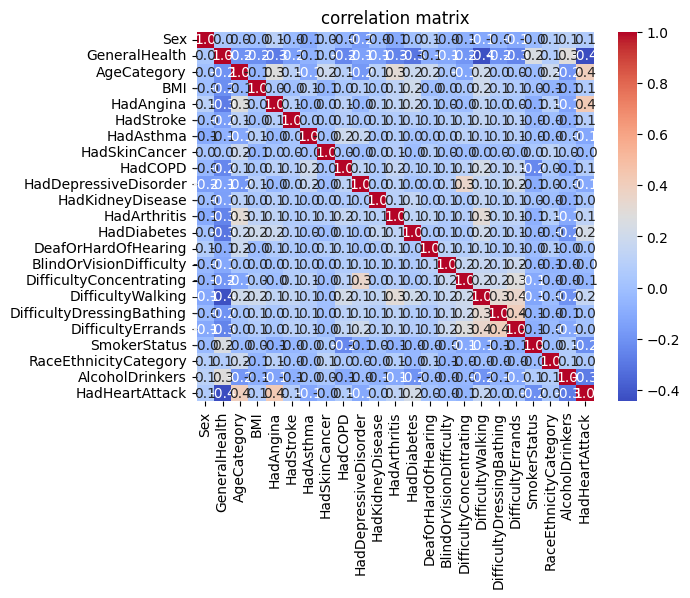

In [ ]:
corr_matrix=df_resampled.corr()
sns.heatmap(corr_matrix,annot=True,fmt='0.01f',cmap='coolwarm')
plt.title('correlation matrix')
plt.show()

### Correlation with 'HadHeartAttack'
To better understand the relationship of each feature with the target variable, let's examine their individual correlations with 'HadHeartAttack'.

Correlations with 'HadHeartAttack':

HadHeartAttack               1.000000
HadAngina                    0.425299
AgeCategory                  0.401394
HadDiabetes                  0.227104
DifficultyWalking            0.151812
HadArthritis                 0.123692
HadStroke                    0.085378
HadCOPD                      0.072920
Sex                          0.066350
BMI                          0.064718
RaceEthnicityCategory        0.040755
HadKidneyDisease             0.026643
DeafOrHardOfHearing          0.023020
DifficultyErrands            0.014915
DifficultyDressingBathing    0.008375
BlindOrVisionDifficulty     -0.030399
HadSkinCancer               -0.038613
DifficultyConcentrating     -0.055217
HadDepressiveDisorder       -0.110150
HadAsthma                   -0.117446
SmokerStatus                -0.217213
AlcoholDrinkers             -0.280409
GeneralHealth               -0.443747
Name: HadHeartAttack, dtype: float64


/tmp/ipykernel_12957/958692775.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations_with_target.index, y=correlations_with_target.values, palette='viridis')


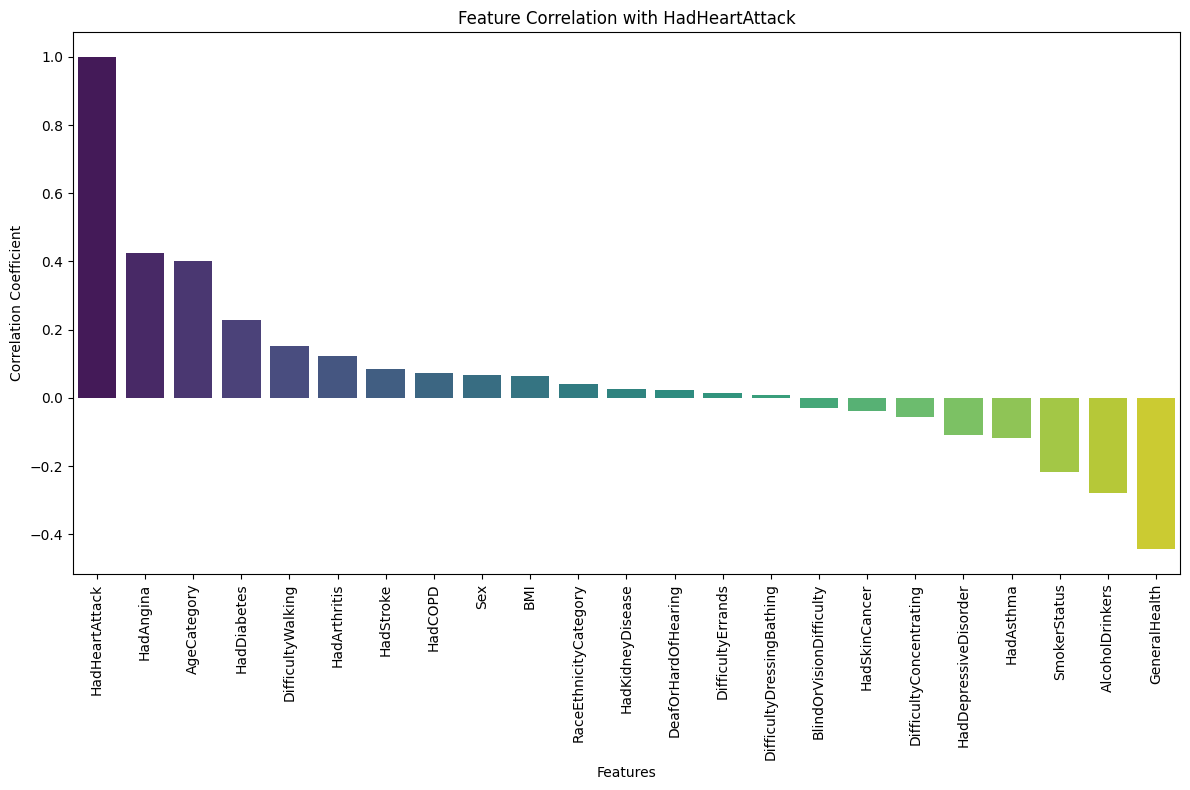

In [ ]:
# Calculate correlations with the target variable 'HadHeartAttack'
correlations_with_target = df_resampled.corr()['HadHeartAttack'].sort_values(ascending=False)

# Display the correlations
print("Correlations with 'HadHeartAttack':\n")
print(correlations_with_target)

# Visualize correlations with target in a bar plot for better readability
plt.figure(figsize=(12, 8))
sns.barplot(x=correlations_with_target.index, y=correlations_with_target.values, palette='viridis')
plt.title('Feature Correlation with HadHeartAttack')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

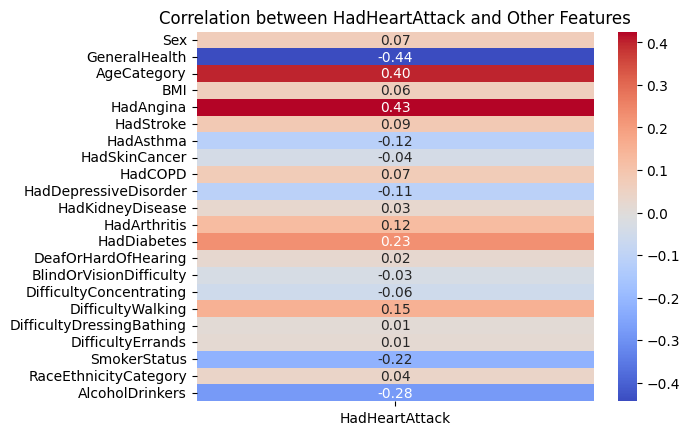

In [ ]:
HadHeartAttack_corr = df_resampled.corr()['HadHeartAttack']
HadHeartAttack_corr = HadHeartAttack_corr.drop('HadHeartAttack')


sns.heatmap(HadHeartAttack_corr.to_frame(), annot=True, fmt='.2f', cmap='coolwarm',
            cbar=True, annot_kws={'size': 10})
plt.title('Correlation between HadHeartAttack and Other Features')
plt.show()

In [ ]:
df_resampled.drop(["BMI","HadAsthma","HadSkinCancer","HadDepressiveDisorder","BlindOrVisionDifficulty","DifficultyConcentrating","DifficultyDressingBathing","DifficultyErrands","SmokerStatus","RaceEthnicityCategory","AlcoholDrinkers"],axis=1,inplace=True)

<Axes: >

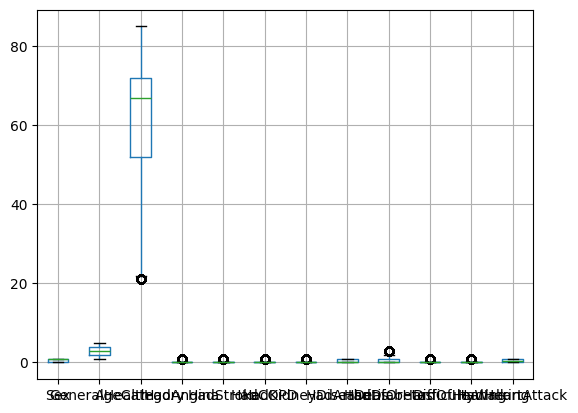

In [ ]:
df_resampled.boxplot()

In [ ]:
def remove_outliers_iqr(df_resampled, exclude_column):
    for col in df_resampled.columns:
        if col == exclude_column:
            continue
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_resampled= df_resampled[(df_resampled[col] >= lower_bound) & (df_resampled[col] <= upper_bound)]
    return df_resampled


df_resampled_cleaned = remove_outliers_iqr(df_resampled, exclude_column='HadHeartAttack')
df_resampled=df_resampled_cleaned

In [ ]:
df_resampled.shape

(203668, 12)

In [ ]:
df_resampled

,Sex,GeneralHealth,AgeCategory,HadAngina,HadStroke,HadCOPD,HadKidneyDisease,HadArthritis,HadDiabetes,DeafOrHardOfHearing,DifficultyWalking,HadHeartAttack
1,0,4,67,0,0,0,0,1,0,0,0,0
2,1,5,62,0,0,0,0,0,0,0,0,0
4,0,3,52,0,0,0,0,0,0,0,0,0
6,0,3,72,0,0,0,0,1,0,0,0,0
9,0,3,85,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
448850,1,3,85,0,0,0,0,1,0,0,0,1
448851,0,2,52,0,0,0,0,0,0,0,0,1
448854,0,3,62,0,0,0,0,1,0,0,0,1
448855,1,4,47,0,0,0,0,0,0,0,0,1


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
features = ['GeneralHealth','AgeCategory','HadHeartAttack','HadAngina','HadStroke','HadCOPD','HadKidneyDisease','HadArthritis','HadDiabetes','DeafOrHardOfHearing','DifficultyWalking']
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_resampled[features])
scaled_df_resampled= pd.DataFrame(scaled_data, columns=features)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd
X = df_resampled[['GeneralHealth','AgeCategory','HadAngina','HadStroke','HadCOPD','HadKidneyDisease','HadArthritis','HadDiabetes','DeafOrHardOfHearing','DifficultyWalking']]
y = df_resampled['HadHeartAttack']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.78
